In [1]:
import pandas as pd
df = pd.read_excel("../data/online_retail_II.xlsx")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [4]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [8]:
df = df.dropna(subset=['Customer ID'])

In [9]:
df = df[df['Quantity'] > 0]

In [10]:
df['TotalPrice'] = df['Quantity'] * df['Price']

In [11]:
df.shape
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [12]:
returns = df[df['Quantity'] < 0].shape[0]
returns

0

In [13]:
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    7414755.963
EIRE               356085.210
Netherlands        268786.000
Germany            202395.321
France             146215.420
Sweden              53171.390
Denmark             50906.850
Spain               47601.420
Switzerland         43921.390
Australia           31446.800
Name: TotalPrice, dtype: float64

In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [15]:
import datetime as dt

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [16]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'count',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,33,372.86
12347.0,3,71,1323.32
12348.0,74,20,222.16
12349.0,43,102,2671.14
12351.0,11,21,300.93


In [17]:
rfm.describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,94.541744,2048.238236
std,96.860633,202.046410,8914.481280
min,1.000000,1.000000,2.950000
25%,18.000000,18.000000,307.987500
50%,53.000000,44.000000,706.020000
75%,136.000000,102.000000,1723.142500
max,374.000000,5570.000000,349164.350000


In [18]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'], 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [19]:
rfm['RFM_score'] = rfm['R_score'].astype(int) + rfm['F_score'].astype(int) + rfm['M_score'].astype(int)

In [20]:
def segment_customer(score):
    if score >= 12:
        return 'High Value'
    elif score >= 8:
        return 'Medium Value'
    else:
        return 'Low Value'

rfm['Segment'] = rfm['RFM_score'].apply(segment_customer)

In [21]:
rfm['Segment'].value_counts()

Segment
Low Value       1634
Medium Value    1448
High Value      1230
Name: count, dtype: int64

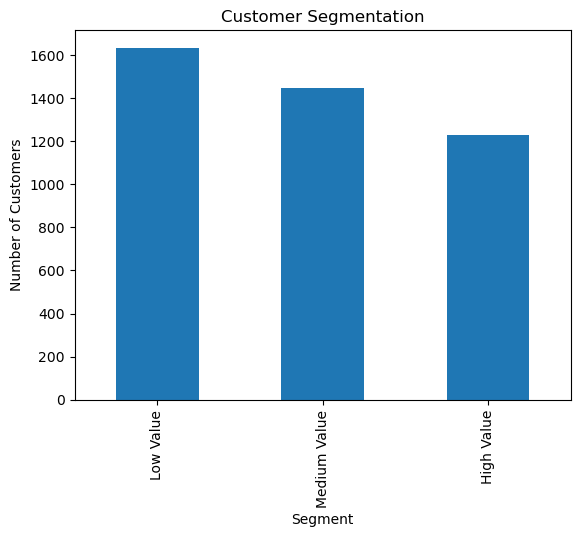

In [22]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar')

plt.title("Customer Segmentation")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

Most customers fall into Low/Medium segment, indicating growth opportunity.

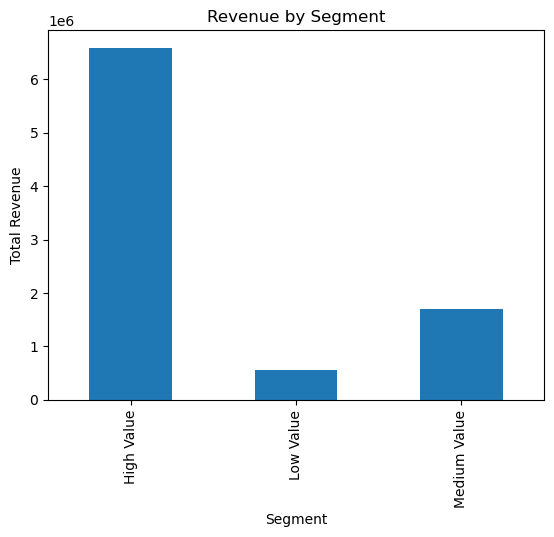

In [23]:
rfm.groupby('Segment')['Monetary'].sum().plot(kind='bar')

plt.title("Revenue by Segment")
plt.ylabel("Total Revenue")
plt.show()

High Value customers generate majority of revenue

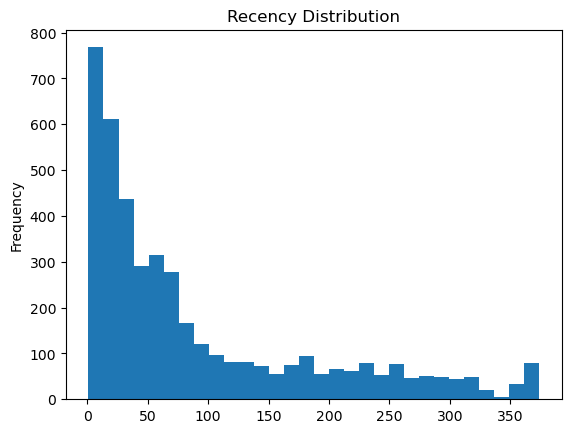

In [24]:
rfm['Recency'].plot(kind='hist', bins=30)

plt.title("Recency Distribution")
plt.show()

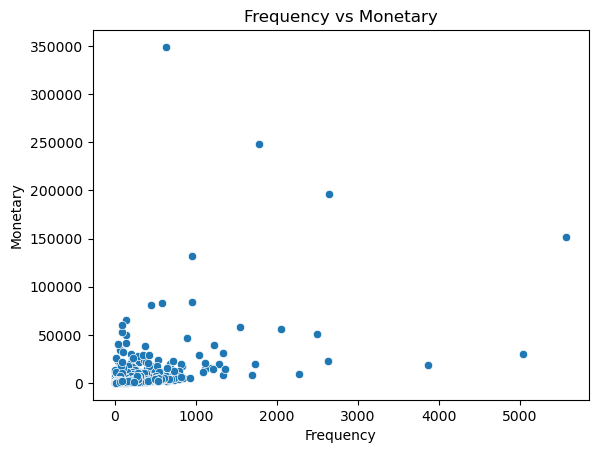

In [25]:
import seaborn as sns

sns.scatterplot(x='Frequency', y='Monetary', data=rfm)

plt.title("Frequency vs Monetary")
plt.show()

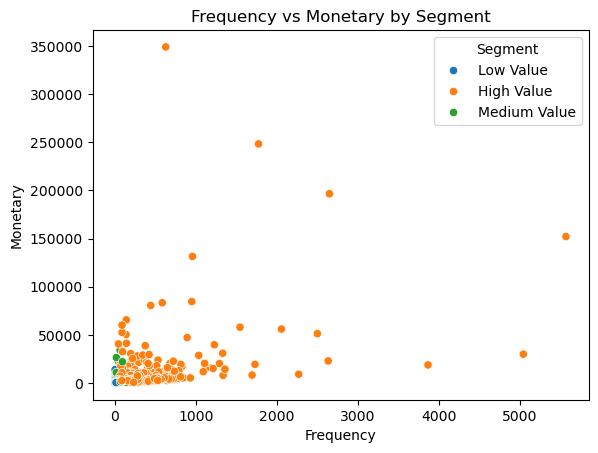

In [26]:
sns.scatterplot(x='Frequency', y='Monetary', hue='Segment', data=rfm)

plt.title("Frequency vs Monetary by Segment")
plt.show()

In [27]:
rfm.sort_values(by='Monetary', ascending=False).head(10)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
Customer ID,,,,,,,,
18102.0,1,627,349164.35,5,5,5,15,High Value
14646.0,10,1773,248396.50,5,5,5,15,High Value
14156.0,7,2648,196566.74,5,5,5,15,High Value
14911.0,1,5570,152147.57,5,5,5,15,High Value
13694.0,9,957,131443.19,5,5,5,15,High Value
17511.0,3,948,84541.17,5,5,5,15,High Value
15061.0,3,584,83284.38,5,5,5,15,High Value
16684.0,15,441,80489.21,5,5,5,15,High Value
16754.0,8,140,65500.07,5,5,5,15,High Value


High Value → retain (loyalty program)
Medium → upsell
Low → marketing push

In [28]:
rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 90 else 0)

In [29]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [32]:
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       571
           1       1.00      1.00      1.00       292

    accuracy                           1.00       863
   macro avg       1.00      1.00      1.00       863
weighted avg       1.00      1.00      1.00       863



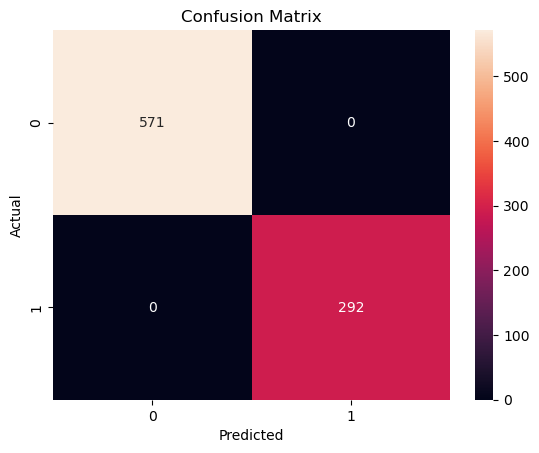

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

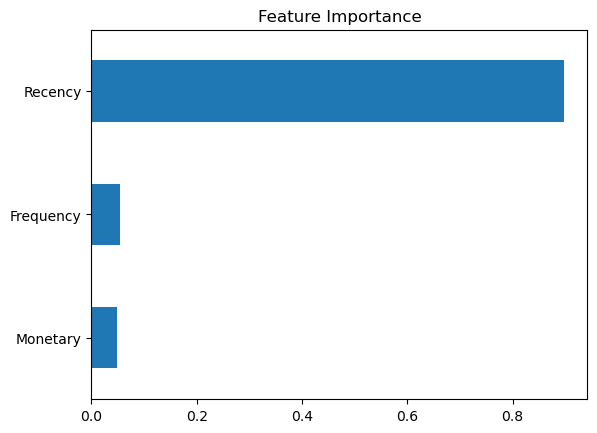

In [35]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [37]:
import pickle

with open("../app/model.pkl", "wb") as f:
    pickle.dump(model, f)

In [38]:
model.predict([[30, 50, 1000]])

C:\Users\nishant\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

In [39]:
import pandas as pd

model.predict(pd.DataFrame([[30,50,1000]], columns=['Recency','Frequency','Monetary']))

array([0])

In [41]:
import os

os.makedirs("../data/processed", exist_ok=True)

In [42]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)